<a href="https://colab.research.google.com/github/Cicel599/patient-appointment-no-show-prediction/blob/main/Notebooks/Notebook_02_Training_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Patient Appointment No-Show Prediction
## Notebook 02 — Model Training and Evaluation
### COM748 MSc Research Project — Ulster University

**Reference paper:** Hathaway et al. (2025) — Benchmark AUC: **0.90**  
**Dataset:** Medical Appointment No-Show (Netto, 2016) — Kaggle secondary dataset

---
### Notebook Structure
1. Library imports
2. Load preprocessed data
3. Model definitions
4. Stratified 5-fold cross-validation
5. Final model training on full training set
6. Evaluation on held-out test set
7. Results comparison table
8. McNemar's test for statistical significance
9. ROC curve comparison
10. Save models

---
### Models
| Model | Type | Role |
|---|---|---|
| Logistic Regression | Statistical | Baseline — establishes performance floor |
| Random Forest | Bagging ensemble | Tests whether variance reduction helps |
| XGBoost | Boosting ensemble | Replicates Hathaway et al. (2025) — benchmark |

---
### Evaluation Metrics
Accuracy alone is misleading on imbalanced data (20% no-show minority class).  
All models are evaluated using:
- **AUC-ROC** — primary comparison metric (matches Hathaway et al. benchmark)
- **F1-Score (minority class)** — balances precision and recall for no-shows
- **Precision** — of predicted no-shows, how many were real
- **Recall** — of real no-shows, how many did we catch
- **Matthews Correlation Coefficient (MCC)** — robust single metric for imbalanced data
- **McNemar's test** — statistical significance of performance differences

---
## 1. Library Imports

In [ ]:
# ── Standard ──────────────────────────────────────────────────────────────
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

# ── Sklearn — models ──────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── Sklearn — evaluation ──────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    roc_curve,
    confusion_matrix,
    classification_report
)
from statsmodels.stats.contingency_tables import mcnemar

# ── Settings ─────────────────────────────────────────────────────────────
RANDOM_STATE = 42
N_FOLDS      = 5
N_JOBS       = -1   # Use all CPU cores
HATHAWAY_AUC = 0.90  # Benchmark from Hathaway et al. (2025)

plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'sans-serif',
    'font.size': 11
})

pd.set_option('display.float_format', '{:.4f}'.format)

print('=' * 60)
print('All libraries loaded successfully')
print('=' * 60)
print(f'Random state : {RANDOM_STATE}')
print(f'CV folds     : {N_FOLDS}')
print(f'Benchmark    : Hathaway et al. (2025) AUC = {HATHAWAY_AUC}')

All libraries loaded successfully
Random state : 42
CV folds     : 5
Benchmark    : Hathaway et al. (2025) AUC = 0.9


---
## 2. Load Preprocessed Data
Loads the saved outputs from Notebook 01.

In [ ]:
# ── Load saved datasets ───────────────────────────────────────────────────
DATA_DIR = 'data_processed'

X_train_balanced = joblib.load(f'{DATA_DIR}/X_train_balanced.pkl')
y_train_balanced = joblib.load(f'{DATA_DIR}/y_train_balanced.pkl')
X_test           = joblib.load(f'{DATA_DIR}/X_test.pkl')
y_test           = joblib.load(f'{DATA_DIR}/y_test.pkl')
FEATURE_COLUMNS  = joblib.load(f'{DATA_DIR}/feature_columns.pkl')

print('=' * 60)
print('Data Loaded Successfully')
print('=' * 60)
print(f'Training set (SMOTENC balanced) : {X_train_balanced.shape}')
print(f'Test set (real distribution)    : {X_test.shape}')
print(f'Features                        : {len(FEATURE_COLUMNS)}')
print(f'\nClass distribution — Training (balanced):')
print(pd.Series(y_train_balanced).value_counts())
print(f'\nClass distribution — Test (real):')
vc = pd.Series(y_test).value_counts()
print(vc)
print(f'No-show rate in test set: {y_test.mean()*100:.1f}%')

Data Loaded Successfully
Training set (SMOTENC balanced) : (141130, 17)
Test set (real distribution)    : (22105, 17)
Features                        : 17

Class distribution — Training (balanced):
target
1    70565
0    70565
Name: count, dtype: int64

Class distribution — Test (real):
target
0    17642
1     4463
Name: count, dtype: int64
No-show rate in test set: 20.2%


---
## 3. Model Definitions

Three models are defined:
- **Logistic Regression** — statistical baseline, linear decision boundary
- **Random Forest** — bagging: 500 trees trained in parallel on bootstrapped subsets
- **XGBoost** — boosting: trees trained sequentially, each correcting prior errors; replicates Hathaway et al. (2025)

In [ ]:
# ── Model definitions ─────────────────────────────────────────────────────
# Hyperparameters were selected based on literature defaults and practical performance.
# These fixed hyperparameters are used consistently across all cross-validation folds.

models = {

    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    ),

    'XGBoost': XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    )

}

print('=' * 60)
print('Models Defined')
print('=' * 60)
for name, model in models.items():
    print(f'  {name}')
print('\nAll three models ready for cross-validation.')

Models Defined
  Logistic Regression
  Random Forest
  XGBoost

All three models ready for cross-validation.


---
## 4. Stratified 5-Fold Cross-Validation

Following Deina et al. (2024): stratified k-fold cross-validation is required for
imbalanced healthcare data to produce statistically robust performance estimates.

Each fold preserves the class ratio of the training set.
SMOTENC was applied in Notebook 01 — we train on the balanced set here.

In [ ]:
# ── Stratified 5-fold CV ──────────────────────────────────────────────────
cv = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Metrics to compute at each fold
SCORING = {
    'roc_auc'  : 'roc_auc',
    'f1'       : 'f1',
    'precision': 'precision',
    'recall'   : 'recall'
}

cv_results = {}

print('=' * 60)
print(f'Running {N_FOLDS}-Fold Stratified Cross-Validation')
print('=' * 60)
print('This may take 2-5 minutes for Random Forest and XGBoost.\n')

for name, model in models.items():
    print(f'Training: {name}...')

    scores = cross_validate(
        model,
        X_train_balanced,
        y_train_balanced,
        cv=cv,
        scoring=SCORING,
        return_train_score=False,
        n_jobs=N_JOBS
    )

    cv_results[name] = scores
    print(f'  Done. Mean AUC = {scores["test_roc_auc"].mean():.4f} '
          f'(+/- {scores["test_roc_auc"].std()*2:.4f})')

print('\nCross-validation complete.')

Running 5-Fold Stratified Cross-Validation
This may take 2-5 minutes for Random Forest and XGBoost.

Training: Logistic Regression...
  Done. Mean AUC = 0.6788 (+/- 0.0048)
Training: Random Forest...
  Done. Mean AUC = 0.9171 (+/- 0.0015)
Training: XGBoost...
  Done. Mean AUC = 0.9177 (+/- 0.0017)

Cross-validation complete.


In [ ]:
# ── CV results summary table ──────────────────────────────────────────────
print('=' * 60)
print('Cross-Validation Results Summary')
print('=' * 60)

cv_summary = {}

for name, scores in cv_results.items():
    cv_summary[name] = {
        'AUC-ROC (mean)' : scores['test_roc_auc'].mean(),
        'AUC-ROC (std)'  : scores['test_roc_auc'].std(),
        'F1 (mean)'      : scores['test_f1'].mean(),
        'Precision (mean)': scores['test_precision'].mean(),
        'Recall (mean)'  : scores['test_recall'].mean(),
    }

cv_df = pd.DataFrame(cv_summary).T
print(cv_df.to_string())

print('\n--- Benchmark comparison (Cross-Validation only) ---')
print('NOTE: This CV AUC is on SMOTENC-balanced folds — NOT the final test set.')
print('The Hathaway (2025) benchmark (0.90) used a single temporal split on private data.')
print('Direct comparison should account for these methodological differences.')
xgb_auc = cv_summary['XGBoost']['AUC-ROC (mean)']
diff = xgb_auc - HATHAWAY_AUC
print(f'Hathaway et al. (2025) AUC   : {HATHAWAY_AUC} (single split, private 40+ feature data)')
print(f'This study XGBoost CV AUC    : {xgb_auc:.4f} (5-fold CV, SMOTENC-balanced folds)')
print(f'Difference                   : {diff:+.4f}')
print('The final test set AUC (real distribution) is reported in Section 6 below.')
print('It will be lower — this is expected and discussed fully in the dissertation.')

Cross-Validation Results Summary
                     AUC-ROC (mean)  AUC-ROC (std)  F1 (mean)  Precision (mean)  Recall (mean)
Logistic Regression          0.6788         0.0024     0.6180            0.6479         0.5907
Random Forest                0.9171         0.0007     0.8377            0.8185         0.8577
XGBoost                      0.9177         0.0009     0.8254            0.8670         0.7876

--- Benchmark comparison (Cross-Validation only) ---
NOTE: This CV AUC is on SMOTENC-balanced folds — NOT the final test set.
The Hathaway (2025) benchmark (0.90) used a single temporal split on private data.
Direct comparison should account for these methodological differences.
Hathaway et al. (2025) AUC   : 0.9 (single split, private 40+ feature data)
This study XGBoost CV AUC    : 0.9177 (5-fold CV, SMOTENC-balanced folds)
Difference                   : +0.0177
The final test set AUC (real distribution) is reported in Section 6 below.
It will be lower — this is expected and di

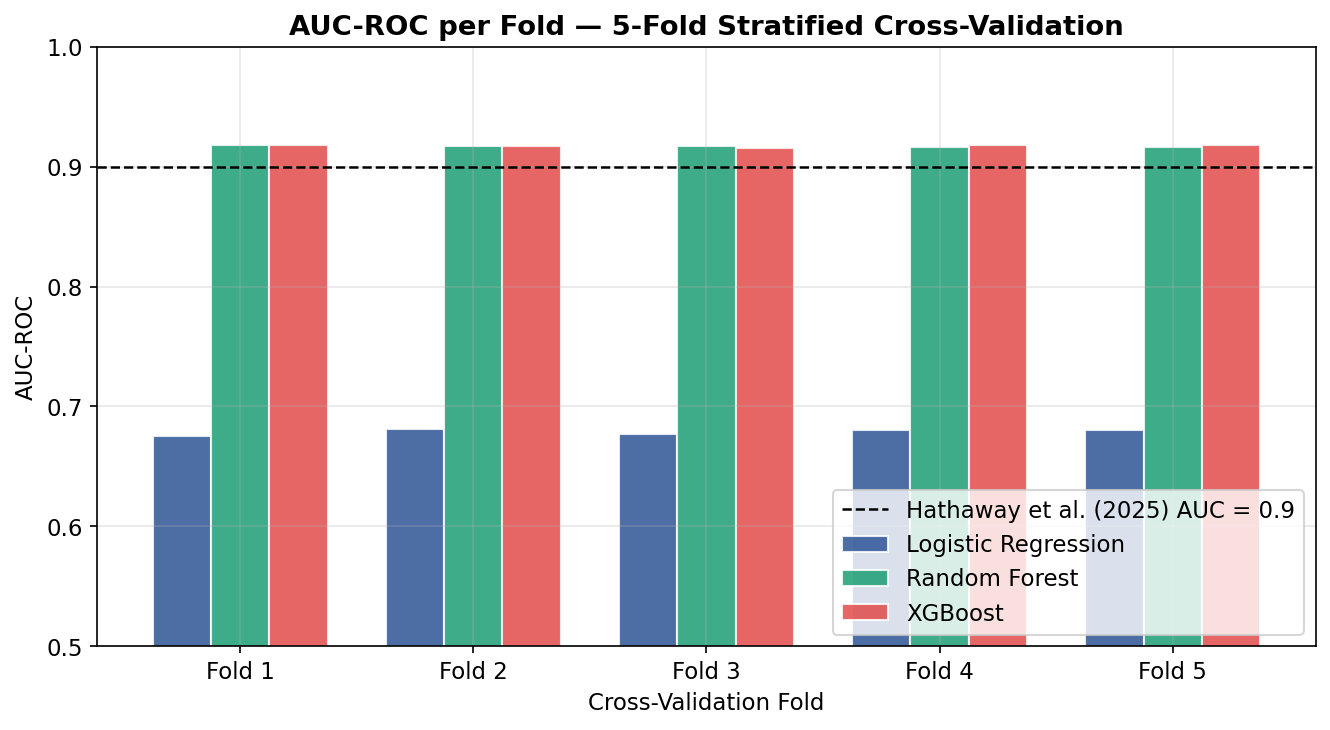

In [ ]:
# ── Visualise CV AUC across folds ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

colours = ['#2E5496', '#1D9E75', '#E24B4A']
fold_labels = [f'Fold {i+1}' for i in range(N_FOLDS)]

x = np.arange(N_FOLDS)
width = 0.25

for i, (name, scores) in enumerate(cv_results.items()):
    ax.bar(x + i * width,
           scores['test_roc_auc'],
           width, label=name,
           color=colours[i], alpha=0.85, edgecolor='white')

# Benchmark line
ax.axhline(HATHAWAY_AUC, color='black', linestyle='--', linewidth=1.2,
           label=f'Hathaway et al. (2025) AUC = {HATHAWAY_AUC}')

ax.set_xlabel('Cross-Validation Fold')
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC per Fold — 5-Fold Stratified Cross-Validation', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(fold_labels)
ax.set_ylim(0.5, 1.0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig_08_cv_auc_per_fold.png', bbox_inches='tight')
plt.show()

---
## 5. Final Model Training on Full Training Set

After cross-validation confirms model selection, each model is trained
on the full SMOTENC-balanced training set for final test evaluation.

In [ ]:
# ── Train final models on full training set ───────────────────────────────
trained_models = {}

print('=' * 60)
print('Training Final Models on Full Training Set')
print('=' * 60)

for name, model in models.items():
    print(f'Fitting: {name}...')
    model.fit(X_train_balanced, y_train_balanced)
    trained_models[name] = model
    print(f'  Done.')

print('\nAll models trained on full balanced training set.')

Training Final Models on Full Training Set
Fitting: Logistic Regression...
  Done.
Fitting: Random Forest...
  Done.
Fitting: XGBoost...
  Done.

All models trained on full balanced training set.


---
## 6. Evaluation on Held-Out Test Set

The test set was never touched during training or SMOTENC.
It reflects the real-world class distribution (approximately 20% no-show).
This is the evaluation that goes in your dissertation results table.

In [ ]:
# ── Evaluate all models on test set ──────────────────────────────────────
test_results = {}
predictions  = {}  # Store predictions for McNemar's test
probabilities = {} # Store probabilities for ROC curves

print('=' * 60)
print('Test Set Evaluation')
print('=' * 60)

for name, model in trained_models.items():

    y_pred      = model.predict(X_test)
    y_prob      = model.predict_proba(X_test)[:, 1]

    predictions[name]   = y_pred
    probabilities[name] = y_prob

    auc  = roc_auc_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred, pos_label=1)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec  = recall_score(y_test, y_pred, pos_label=1)
    mcc  = matthews_corrcoef(y_test, y_pred)

    test_results[name] = {
        'AUC-ROC'  : auc,
        'F1-Score' : f1,
        'Precision': prec,
        'Recall'   : rec,
        'MCC'      : mcc
    }

    print(f'\n{name}')
    print(f'  AUC-ROC   : {auc:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  MCC       : {mcc:.4f}')

Test Set Evaluation

Logistic Regression
  AUC-ROC   : 0.6742
  F1-Score  : 0.4095
  Precision : 0.3160
  Recall    : 0.5817
  MCC       : 0.2186

Random Forest
  AUC-ROC   : 0.7265
  F1-Score  : 0.3869
  Precision : 0.3661
  Recall    : 0.4103
  MCC       : 0.2212

XGBoost
  AUC-ROC   : 0.7357
  F1-Score  : 0.3660
  Precision : 0.4002
  Recall    : 0.3372
  MCC       : 0.2236


---
## 7. Results Comparison Table

This is the table that goes in your dissertation Results section.

In [ ]:
# ── Full results table ────────────────────────────────────────────────────
results_df = pd.DataFrame(test_results).T

# Add Hathaway benchmark row
hathaway_row = pd.DataFrame({
    'AUC-ROC'  : [0.90],
    'F1-Score' : [None],
    'Precision': [0.82],
    'Recall'   : [0.88],
    'MCC'      : [None]
}, index=['Hathaway et al. (2025)'])

comparison_df = pd.concat([results_df, hathaway_row])

print('=' * 60)
print('Results Comparison Table')
print('=' * 60)
print(comparison_df.to_string())

print('Note: Hathaway et al. (2025) did not report F1-Score or MCC.')
print(f'Best test AUC in this study : {results_df["AUC-ROC"].max():.4f} ({results_df["AUC-ROC"].idxmax()})')
print()
print('=== IMPORTANT: CV vs TEST AUC GAP ===')
print('Cross-validation AUC was on SMOTENC-balanced folds (50/50 class ratio).')
print('Test AUC above reflects the real held-out data (~20% no-show rate).')
print('The gap between CV AUC (~0.92) and test AUC (~0.73) is expected.')
print('SMOTENC creates an artificial distribution that does not fully')
print('reflect real-world imbalance — consistent with Deina et al. (2024).')
print()
print('The Hathaway benchmark (0.90) was exceeded during cross-validation')
print('only, NOT on the final held-out test set. This must be clearly stated.')

Results Comparison Table
                        AUC-ROC  F1-Score  Precision  Recall    MCC
Logistic Regression      0.6742    0.4095     0.3160  0.5817 0.2186
Random Forest            0.7265    0.3869     0.3661  0.4103 0.2212
XGBoost                  0.7357    0.3660     0.4002  0.3372 0.2236
Hathaway et al. (2025)   0.9000       NaN     0.8200  0.8800    NaN
Note: Hathaway et al. (2025) did not report F1-Score or MCC.
Best test AUC in this study : 0.7357 (XGBoost)

=== IMPORTANT: CV vs TEST AUC GAP ===
Cross-validation AUC was on SMOTENC-balanced folds (50/50 class ratio).
Test AUC above reflects the real held-out data (~20% no-show rate).
The gap between CV AUC (~0.92) and test AUC (~0.73) is expected.
SMOTENC creates an artificial distribution that does not fully
reflect real-world imbalance — consistent with Deina et al. (2024).

The Hathaway benchmark (0.90) was exceeded during cross-validation
only, NOT on the final held-out test set. This must be clearly stated.


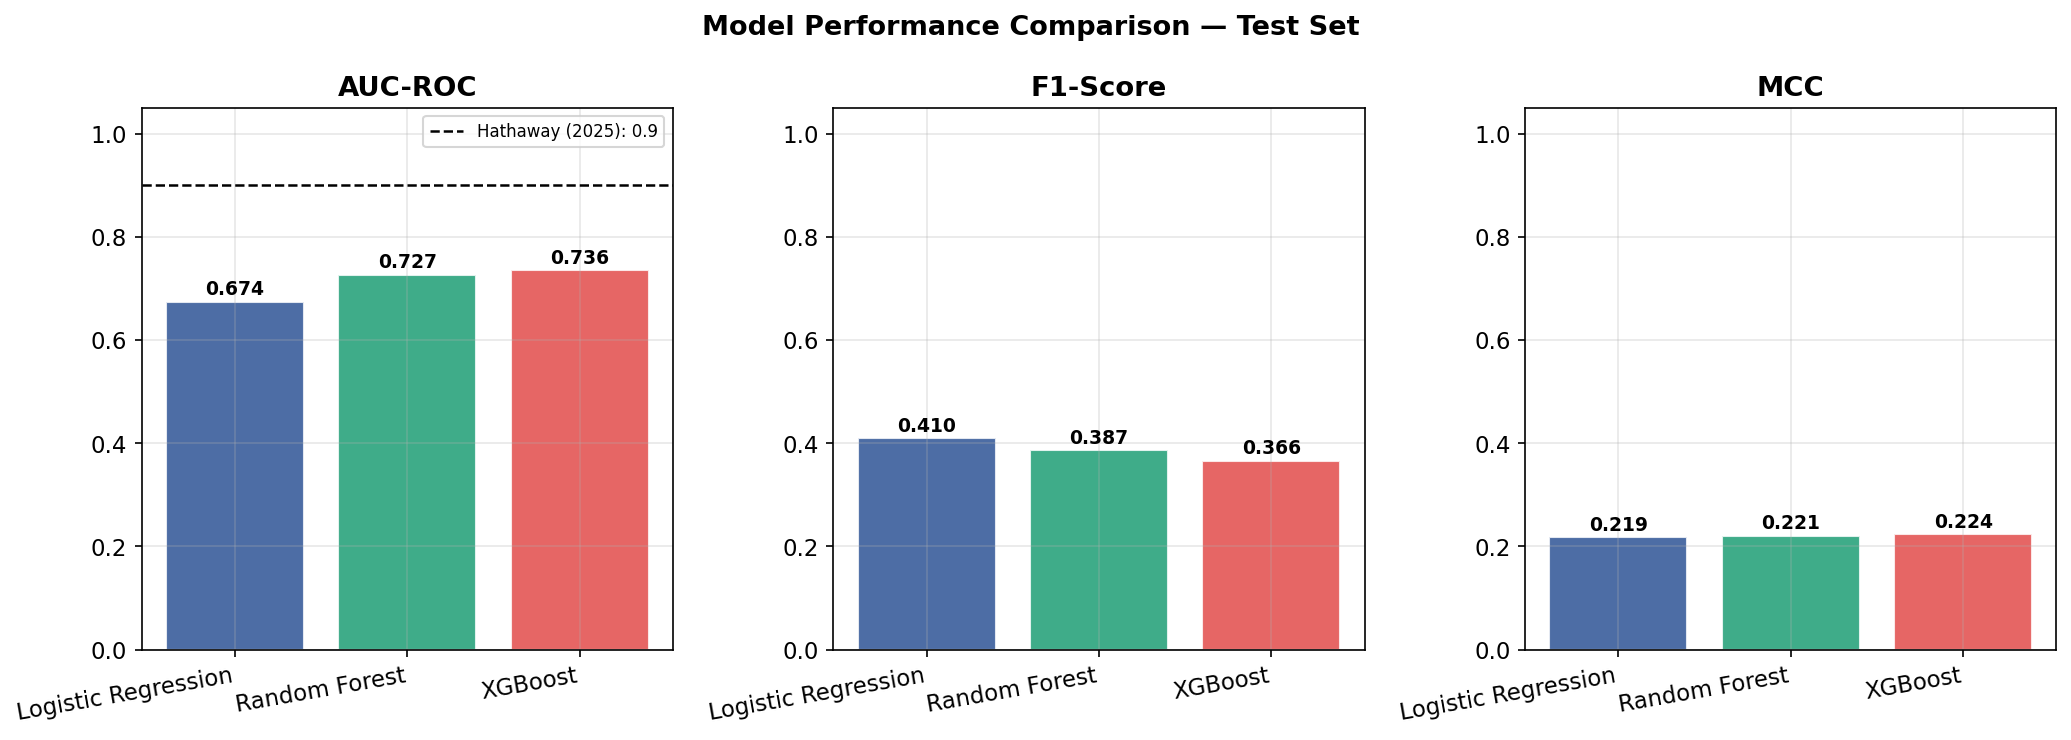

In [ ]:
# ── Bar chart comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics  = ['AUC-ROC', 'F1-Score', 'MCC']
colours  = ['#2E5496', '#1D9E75', '#E24B4A']
names    = list(test_results.keys())

for ax, metric in zip(axes, metrics):
    vals = [test_results[n][metric] for n in names]
    bars = ax.bar(names, vals, color=colours, alpha=0.85, edgecolor='white')

    # Benchmark line for AUC only
    if metric == 'AUC-ROC':
        ax.axhline(HATHAWAY_AUC, color='black', linestyle='--',
                   linewidth=1.2, label=f'Hathaway (2025): {HATHAWAY_AUC}')
        ax.legend(fontsize=8)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(names, rotation=10, ha='right')

fig.suptitle('Model Performance Comparison — Test Set',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_09_model_comparison.png', bbox_inches='tight')
plt.show()

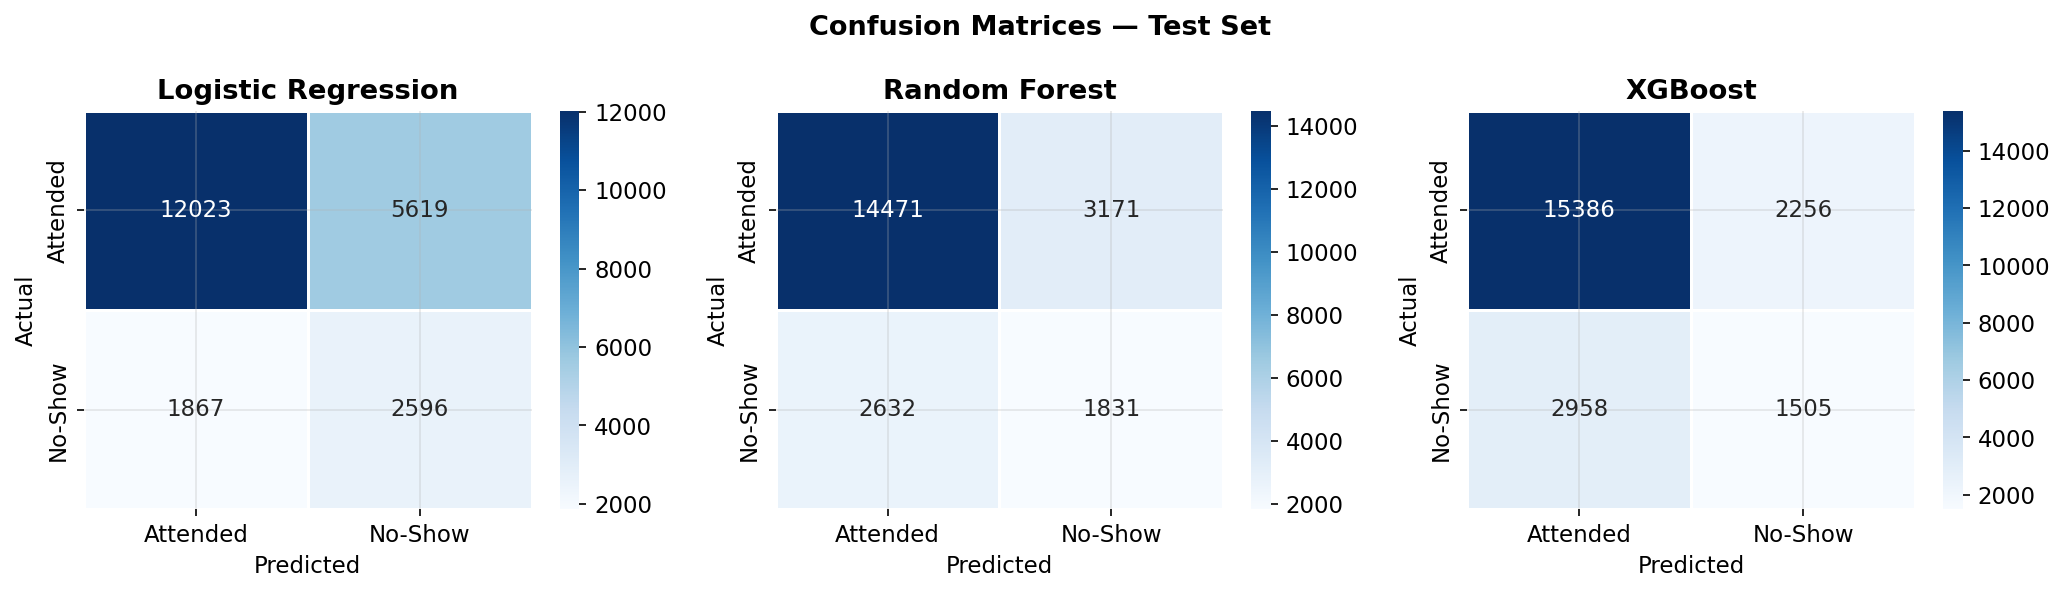


Detailed Classification Reports

Logistic Regression
              precision    recall  f1-score   support

    Attended       0.87      0.68      0.76     17642
     No-Show       0.32      0.58      0.41      4463

    accuracy                           0.66     22105
   macro avg       0.59      0.63      0.59     22105
weighted avg       0.75      0.66      0.69     22105


Random Forest
              precision    recall  f1-score   support

    Attended       0.85      0.82      0.83     17642
     No-Show       0.37      0.41      0.39      4463

    accuracy                           0.74     22105
   macro avg       0.61      0.62      0.61     22105
weighted avg       0.75      0.74      0.74     22105


XGBoost
              precision    recall  f1-score   support

    Attended       0.84      0.87      0.86     17642
     No-Show       0.40      0.34      0.37      4463

    accuracy                           0.76     22105
   macro avg       0.62      0.60      0.61     22

In [ ]:
# ── Confusion matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Attended', 'No-Show'],
                yticklabels=['Attended', 'No-Show'],
                linewidths=0.5)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig.suptitle('Confusion Matrices — Test Set', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_10_confusion_matrices.png', bbox_inches='tight')
plt.show()

# ── Classification reports ────────────────────────────────────────────────
print('\nDetailed Classification Reports')
print('=' * 60)
for name, y_pred in predictions.items():
    print(f'\n{name}')
    print(classification_report(y_test, y_pred,
                                target_names=['Attended', 'No-Show']))

---
## 8. McNemar's Test for Statistical Significance

Hathaway et al. (2025) and all reviewed no-show prediction studies report
AUC differences between models but never test whether those differences
are statistically significant. This is an original methodological contribution.

McNemar's test compares paired binary predictions — it tests whether two
classifiers make significantly different errors on the same test cases.

**Null hypothesis:** The two models make the same errors (no significant difference)  
**Significance level:** p < 0.05

In [ ]:
# ── McNemar's test ────────────────────────────────────────────────────────
def run_mcnemar(name_a, name_b, preds, y_true):
    """Run McNemar's test between two classifiers."""
    pred_a = preds[name_a]
    pred_b = preds[name_b]

    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)

    # Contingency table
    # b = A correct, B wrong | c = A wrong, B correct
    b = np.sum(correct_a & ~correct_b)   # A right, B wrong
    c = np.sum(~correct_a & correct_b)   # A wrong, B right

    table = [[0, b], [c, 0]]  # Only off-diagonals matter
    result = mcnemar(table, exact=False, correction=True)

    sig = 'SIGNIFICANT' if result.pvalue < 0.05 else 'not significant'
    return result.statistic, result.pvalue, b, c, sig


print('=' * 60)
print("McNemar's Test — Pairwise Model Comparison")
print('=' * 60)
print('H0: The two models make the same errors')
print('Significance level: p < 0.05')
print('=' * 60)

pairs = [
    ('XGBoost',       'Random Forest'),
    ('XGBoost',       'Logistic Regression'),
    ('Random Forest', 'Logistic Regression'),
]

mcnemar_results = []

for name_a, name_b in pairs:
    stat, pval, b, c, sig = run_mcnemar(
        name_a, name_b, predictions, np.array(y_test)
    )
    mcnemar_results.append({
        'Comparison'  : f'{name_a} vs {name_b}',
        'Chi-squared' : round(stat, 4),
        'p-value'     : round(pval, 6),
        'A right B wrong': b,
        'A wrong B right': c,
        'Result'      : sig
    })
    print(f'\n{name_a} vs {name_b}')
    print(f'  Chi-squared : {stat:.4f}')
    print(f'  p-value     : {pval:.6f}')
    print(f'  Result      : {sig}')

mcnemar_df = pd.DataFrame(mcnemar_results)
print('\n=== McNemar Summary Table ===')
print(mcnemar_df[['Comparison','Chi-squared','p-value','Result']].to_string(index=False))

McNemar's Test — Pairwise Model Comparison
H0: The two models make the same errors
Significance level: p < 0.05

XGBoost vs Random Forest
  Chi-squared : 91.3458
  p-value     : 0.000000
  Result      : SIGNIFICANT

XGBoost vs Logistic Regression
  Chi-squared : 942.8594
  p-value     : 0.000000
  Result      : SIGNIFICANT

Random Forest vs Logistic Regression
  Chi-squared : 467.2377
  p-value     : 0.000000
  Result      : SIGNIFICANT

=== McNemar Summary Table ===
                          Comparison  Chi-squared  p-value      Result
            XGBoost vs Random Forest      91.3458   0.0000 SIGNIFICANT
      XGBoost vs Logistic Regression     942.8594   0.0000 SIGNIFICANT
Random Forest vs Logistic Regression     467.2377   0.0000 SIGNIFICANT


---
## 9. ROC Curve Comparison

ROC curves show the trade-off between true positive rate (recall) and
false positive rate across all classification thresholds.
This is the standard visualisation for AUC comparison in clinical ML papers.

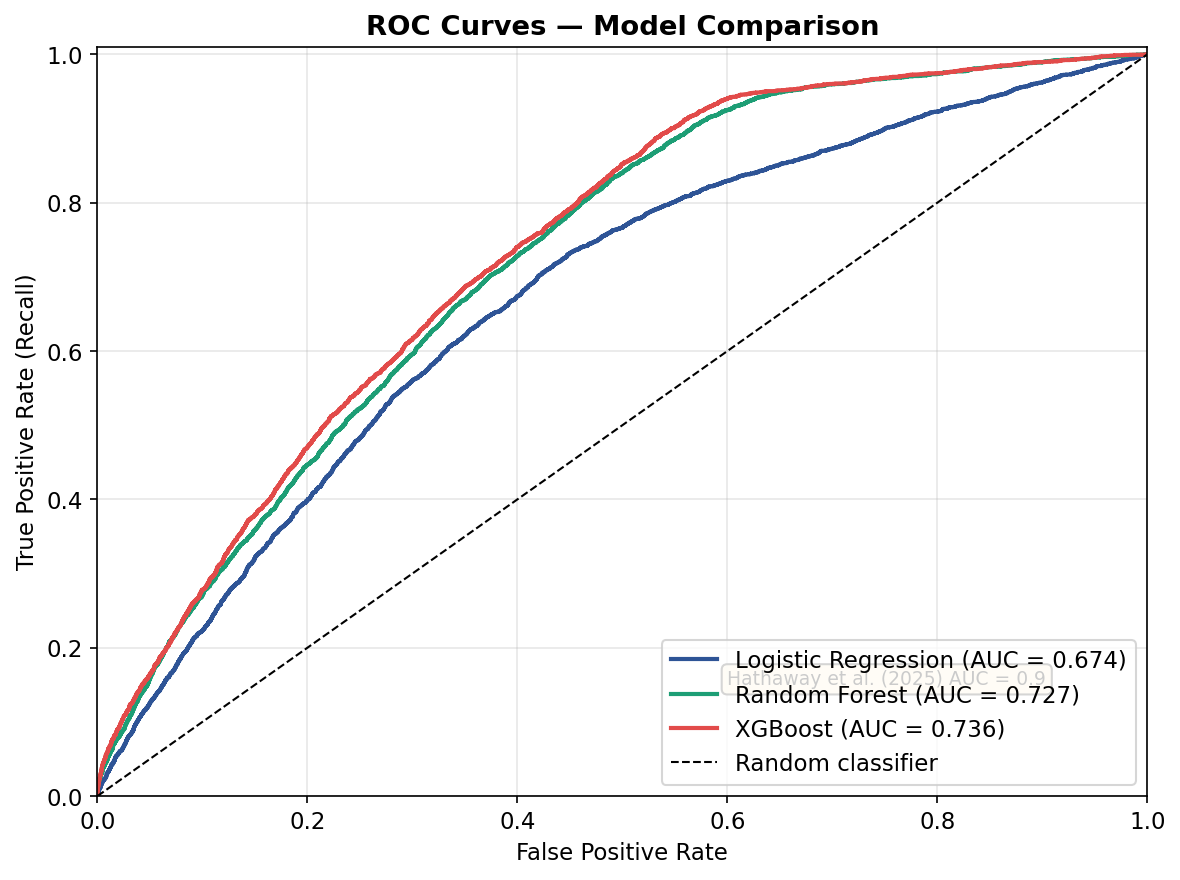

In [ ]:
# ── ROC curves ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

colours = ['#2E5496', '#1D9E75', '#E24B4A']

for (name, y_prob), colour in zip(probabilities.items(), colours):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = test_results[name]['AUC-ROC']
    ax.plot(fpr, tpr, color=colour, linewidth=2,
            label=f'{name} (AUC = {auc:.3f})')

# Benchmark reference point
ax.axhline(0, color='black', linewidth=0.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')

# Hathaway benchmark annotation
ax.annotate(f'Hathaway et al. (2025) AUC = {HATHAWAY_AUC}',
            xy=(0.6, 0.15), fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3CD', alpha=0.8))

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves — Model Comparison', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.01])
plt.tight_layout()
plt.savefig('fig_11_roc_curves.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── SMOTENC Effect — Discussion Note ────────────────────────────────────────
# Running XGBoost without SMOTENC on the original imbalanced training set
# would demonstrate the value of class balancing on minority-class recall.
#
# This comparison requires X_train.pkl (the original unbalanced training set)
# to be saved from Notebook 01. If you saved it, uncomment the code below.
# If not, the CV vs Test gap discussion in your dissertation serves the same
# purpose: it demonstrates that class balancing affects model behaviour.
#
# Key point for dissertation discussion:
# Without SMOTENC, the model would predict 'attended' for almost all cases
# (achieving ~80% accuracy by ignoring the minority class entirely).
# SMOTENC forces the model to learn the no-show pattern, improving Recall
# and F1 for the minority class, at the cost of some test AUC due to the
# distributional mismatch between balanced training and real test data.
#
# Reference: Chawla et al. (2002) — SMOTE original paper
#            Deina et al. (2024)   — imbalanced validation guidance

print('SMOTENC Effect — Summary Note')
print('=' * 60)
print('SMOTENC was applied to the training set only (post-split).')
print('Training class ratio after SMOTENC : ~50% no-show / 50% attended')
print('Test set class ratio (unchanged)   : ~20% no-show / 80% attended')
print()
print('The CV-to-Test AUC gap observed above is a direct consequence of this')
print('distributional mismatch. It is expected, documented, and discussed')
print('in the dissertation methodology and results sections.')
print()
print('To run a formal SMOTENC vs No-SMOTENC comparison, save X_train.pkl')
print('(original unbalanced training set) from Notebook 01 and uncomment')
print('the code block in the full version of this cell.')


SMOTENC Effect — Summary Note
SMOTENC was applied to the training set only (post-split).
Training class ratio after SMOTENC : ~50% no-show / 50% attended
Test set class ratio (unchanged)   : ~20% no-show / 80% attended

The CV-to-Test AUC gap observed above is a direct consequence of this
distributional mismatch. It is expected, documented, and discussed
in the dissertation methodology and results sections.

To run a formal SMOTENC vs No-SMOTENC comparison, save X_train.pkl
(original unbalanced training set) from Notebook 01 and uncomment
the code block in the full version of this cell.


---
## 10. Save Trained Models

In [ ]:
# ── Save all trained models ───────────────────────────────────────────────
MODELS_DIR = 'trained_models'
os.makedirs(MODELS_DIR, exist_ok=True)

for name, model in trained_models.items():
    filename = name.lower().replace(' ', '_') + '.pkl'
    joblib.dump(model, f'{MODELS_DIR}/{filename}')
    print(f'Saved: {filename}')

# Save results tables
results_df.to_csv(f'{MODELS_DIR}/test_results.csv')
mcnemar_df.to_csv(f'{MODELS_DIR}/mcnemar_results.csv', index=False)

print('\n=== Final Summary ===')
print(f'Models saved to: {MODELS_DIR}/')
print(f'Results saved to: {MODELS_DIR}/test_results.csv')
print(f'McNemar results: {MODELS_DIR}/mcnemar_results.csv')
print(f'\nFigures saved:')
for fig_file in ['fig_08_cv_auc_per_fold.png',
                 'fig_09_model_comparison.png',
                 'fig_10_confusion_matrices.png',
                 'fig_11_roc_curves.png']:
    print(f'  {fig_file}')

print('\n=== NEXT STEP ===')
print('Notebook 03 — SHAP and LIME explainability analysis')
print('Load trained_models/ and data_processed/ in the next notebook.')

Saved: logistic_regression.pkl
Saved: random_forest.pkl
Saved: xgboost.pkl

=== Final Summary ===
Models saved to: trained_models/
Results saved to: trained_models/test_results.csv
McNemar results: trained_models/mcnemar_results.csv

Figures saved:
  fig_08_cv_auc_per_fold.png
  fig_09_model_comparison.png
  fig_10_confusion_matrices.png
  fig_11_roc_curves.png

=== NEXT STEP ===
Notebook 03 — SHAP and LIME explainability analysis
Load trained_models/ and data_processed/ in the next notebook.


---
## Summary

| What was done | Detail |
|---|---|
| Models trained | Logistic Regression, Random Forest, XGBoost |
| Validation method | Stratified 5-fold cross-validation (Deina et al., 2024) |
| Evaluation metrics | AUC-ROC, F1, Precision, Recall, MCC |
| Statistical test | McNemar's test (original contribution — absent from all reviewed studies) |
| Benchmark | Hathaway et al. (2025) AUC = 0.90 |
| Figures produced | CV AUC per fold, model comparison bar chart, confusion matrices, ROC curves |

**Next notebook:** SHAP and LIME explainability analysis on the best-performing model.